In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import librosa
import random
import cv2
from matplotlib import cm

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from transformers import Resampler, BandPassFilter, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor, WaveletDenoiser, NoiseAdder, Normalizer

from config import TEST_SIZE, SEED, MAX_DURATION, MIN_DURATION, SAMPLING_RATE, N_MELS, N_FFT

In [3]:
def plot_mel_spectrogram(y, sr=SAMPLING_RATE, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax);

# Conformación del Dataset Final

In [4]:
df = pd.read_csv('./dataset/icbhi/ICBHI_ciclos_metadata.csv')

In [5]:
df['label'] = np.where((df['crackles'] == 0) & (df['wheezes'] == 0), 0, 1)
df.head()

,patient,recording_index,location,mode,instrument,cycle_number,start_sec,end_sec,duration_sec,crackles,wheezes,cycle_wav_file,wav_base_file,age,sex,adult_bmi,child_weight,child_height,diagnosis,label
0,101,1b1,Al,sc,Meditron,1,0.036,0.579,0.543,0,0,101_1b1_Al_sc_Meditron_cycle1.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
1,101,1b1,Al,sc,Meditron,2,0.579,2.450,1.871,0,0,101_1b1_Al_sc_Meditron_cycle2.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
2,101,1b1,Al,sc,Meditron,3,2.450,3.893,1.443,0,0,101_1b1_Al_sc_Meditron_cycle3.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
3,101,1b1,Al,sc,Meditron,4,3.893,5.793,1.900,0,0,101_1b1_Al_sc_Meditron_cycle4.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
4,101,1b1,Al,sc,Meditron,5,5.793,7.521,1.728,0,0,101_1b1_Al_sc_Meditron_cycle5.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0


## Duración de los ciclos respiratorios
La aplicación debería contar con un instructivo mostrando el ritmo de respiración esperado. De esta manera los ciclos detectados por el "segmentador" tendrán mas o menos la misma duración, facilitando la segmentación. 

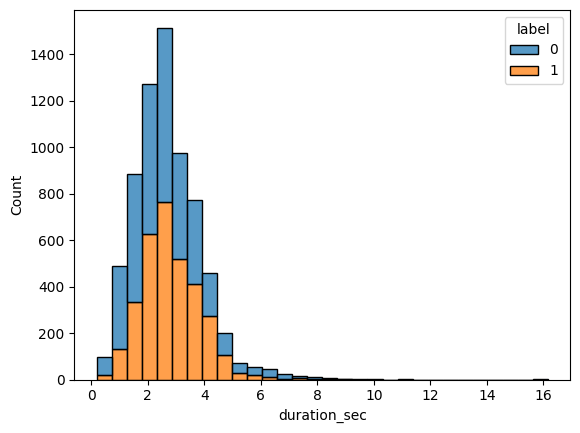

In [6]:
sns.histplot(data=df, x='duration_sec', bins=30, hue='label', multiple='stack');

Las duracion sugerida por el instructivo debería estar en el bulk de la distribución observada.  

¿ Qué hacemos con los ciclos que son demasiado cortos? La segmentación no tolera ciclos demasiado cortos.  

Tampoco debería tolerar los demasiado largos, pero esos son pocos y eliminarlos no es tan costoso.

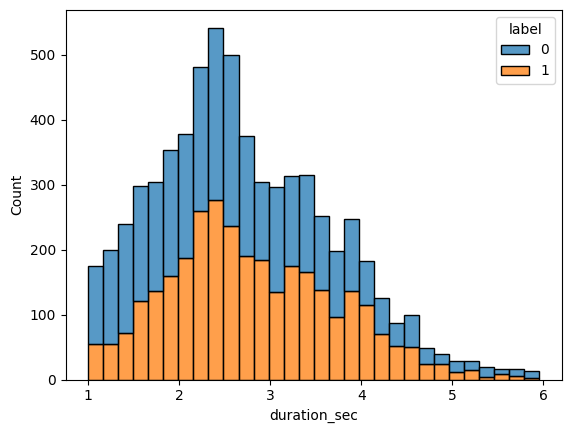

In [7]:
df = df[df['duration_sec'] < MAX_DURATION].copy()
df = df[df['duration_sec'] > MIN_DURATION].copy()

sns.histplot(data=df, x='duration_sec', bins=30, hue='label', multiple='stack');

Opción alternativa: multiplicar los audios cortos y recortar los largos.

## Versiones del dataset final
Se plantean dos versiones del dataset final:
1. Versión completa: contiene todos los ciclos respiratorios de la ICBHI RSDB.
    + Ventajas:
        + Mayor cantidad de datos
        + Capa MixStyles en CNN puede usar información adicional (?)
        + En caso de extenderse el uso del modelo a estetoscopios digitales no habría que hacer cambios.
    + Desventajas:
        + Dificultad de adaptar al dominio de smartphones
        + Costo computacional alto (mi máquina no puede correr CV se SK-Learn)
2. Versión filtrada: sólo los audios grabados con el micrófono AKGC417L o desde la tráquea.
    + Ventajas:
        + Menor costo computacional
        + Menor dificultad en adaptar al dominio
        + Más representativo de los audios esperados en producción
    + Desventajas:
        + Pérdida de datos
        + Más específico al caso (puede ser una ventaja también, no aprendería cosas innecesarias)

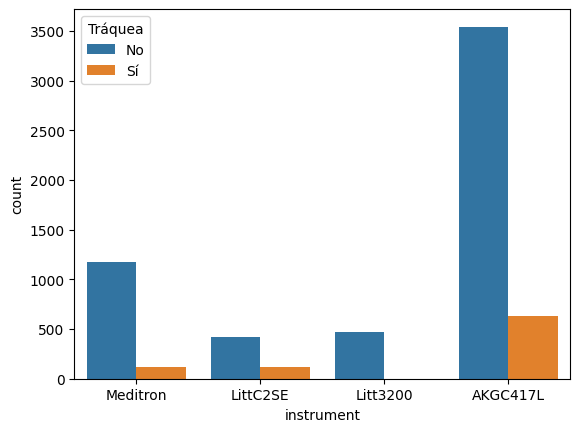

In [8]:
sns.countplot(data=df, x='instrument', hue=df['location'] == 'Tc')
plt.legend(title='Tráquea', labels=['No', 'Sí']);

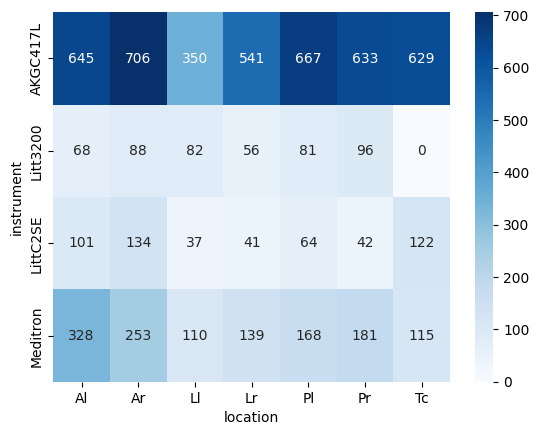

In [9]:
sns.heatmap(pd.crosstab(df['instrument'], df['location']), annot=True, fmt='d', cmap='Blues');

## Balancear

Primero miramos la etiqueta objetivo del futuro modelo

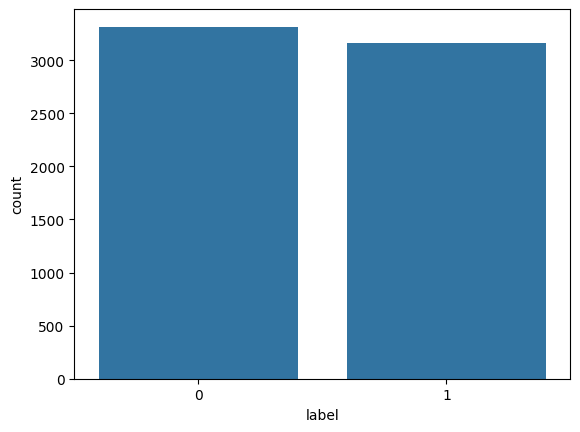

In [10]:
sns.countplot(data=df, x='label');

# Armado del dataset

In [23]:
dataset = 'bp_wd'

os.makedirs(f'./dataset/ciclos_procesados/{dataset}', exist_ok=True)

In [12]:
X = df['cycle_wav_file'].tolist()
y = df['label'].tolist()

X = [os.path.join('./dataset/audios_ciclos/', path) for path in X]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

In [13]:
noise_paths = os.listdir('./audios_propios/ruido')
noise_paths = [os.path.join('./audios_propios/ruido/', path) for path in noise_paths]

test_noise_paths = os.listdir('./audios_propios/ruido_test')
test_noise_paths = [os.path.join('./audios_propios/ruido_test/', path) for path in test_noise_paths]

In [14]:
random.seed(SEED)

resampler = Resampler()
X_train_resampled = resampler.fit_transform(X_train)
X_test_resampled = resampler.transform(X_test)

In [15]:
white_noise_adder = NoiseAdder(noise_files=[], mode='white', snr_min=5, snr_max=10, random_state=SEED)
real_noise_adder = NoiseAdder(noise_files=noise_paths, mode='pool', snr_min=4, snr_max=7, random_state=SEED)
real_noise_adder_strong = NoiseAdder(noise_files=noise_paths, mode='pool', snr_min=1, snr_max=3, random_state=SEED)

real_noise_adder_test = NoiseAdder(noise_files=test_noise_paths, mode='pool', snr_min=4, snr_max=7, random_state=SEED)
real_noise_adder_test_strong = NoiseAdder(noise_files=test_noise_paths, mode='pool', snr_min=1, snr_max=3, random_state=SEED)

In [16]:
indices_white_train = random.sample(range(len(X_train_resampled)), int(0.10 * len(X_train_resampled)))
indices_real_train  = random.sample(range(len(X_train_resampled)), int(0.90 * len(X_train_resampled)))
indices_real_strong_train = random.sample(range(len(X_train_resampled)), int(0.90 * len(X_train_resampled)))

indices_real_test  = random.sample(range(len(X_test_resampled)), int(0.90 * len(X_test_resampled)))
indices_real_strong_test = random.sample(range(len(X_test_resampled)), int(0.90 * len(X_test_resampled)))

In [17]:
X_train_white = white_noise_adder.transform([X_train_resampled[i] for i in indices_white_train])
X_train_real  = real_noise_adder.transform([X_train_resampled[i] for i in indices_real_train])
X_train_real_strong = real_noise_adder_strong.transform([X_train_resampled[i] for i in indices_real_strong_train])

X_test_real  = real_noise_adder_test.transform([X_test_resampled[i] for i in indices_real_test])
X_test_real_strong = real_noise_adder_test_strong.transform([X_test_resampled[i] for i in indices_real_strong_test])

In [18]:
from transformers import WaveletDenoiser

wavelet_denoiser = WaveletDenoiser()

X_train_real = wavelet_denoiser.fit_transform(X_train_real)
X_train_real_strong = wavelet_denoiser.transform(X_train_real_strong)

X_test_real = wavelet_denoiser.transform(X_test_real)
X_test_real_strong = wavelet_denoiser.transform(X_test_real_strong)

In [19]:
X_train_augmented = (
    X_train_resampled +
    X_train_white +
    X_train_real +
    X_train_real_strong
)
y_train_augmented = (
    y_train +
    [y_train[i] for i in indices_white_train] +
    [y_train[i] for i in indices_real_train] +
    [y_train[i] for i in indices_real_strong_train]
)

X_test_augmented = (
    X_test_resampled +
    X_test_real +
    X_test_real_strong
)
y_test_augmented = (
    y_test +
    [y_test[i] for i in indices_real_test] +
    [y_test[i] for i in indices_real_strong_test]
)

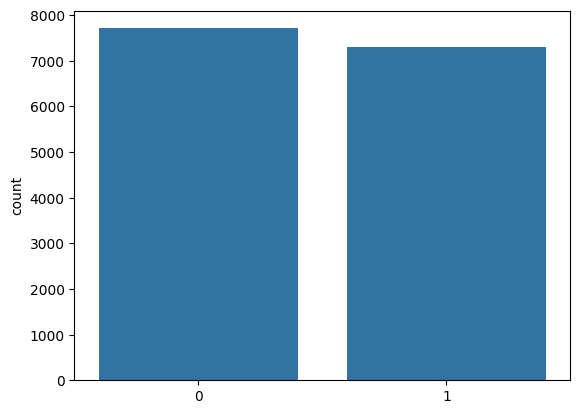

In [20]:
sns.countplot(x=y_train_augmented);

#### Mel espectrograma

In [21]:
pipeline_melspec = Pipeline([
    ('bandpass', BandPassFilter()),
    ('melspec', MelSpectrogramTransformer()),
    ('pad', SpectrogramPadder()),
    ('flatten', FlattenTransformer())
])

In [ ]:
X_train_melspecs_aug = pipeline_melspec.fit_transform(X_train_augmented)
# X_train_melspecs = pipeline_melspec.transform(X_train_resampled)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [ ]:
X_test_melspecs_aug = pipeline_melspec.transform(X_test_augmented)
# X_test_melspecs = pipeline_melspec.transform(X_test_resampled)

In [ ]:
# print(X_train_melspecs.shape, X_test_melspecs.shape)

print(X_train_melspecs_aug.shape, X_test_melspecs_aug.shape)

(5181, 47616) (1296, 47616)
(15023, 47616) (3628, 47616)


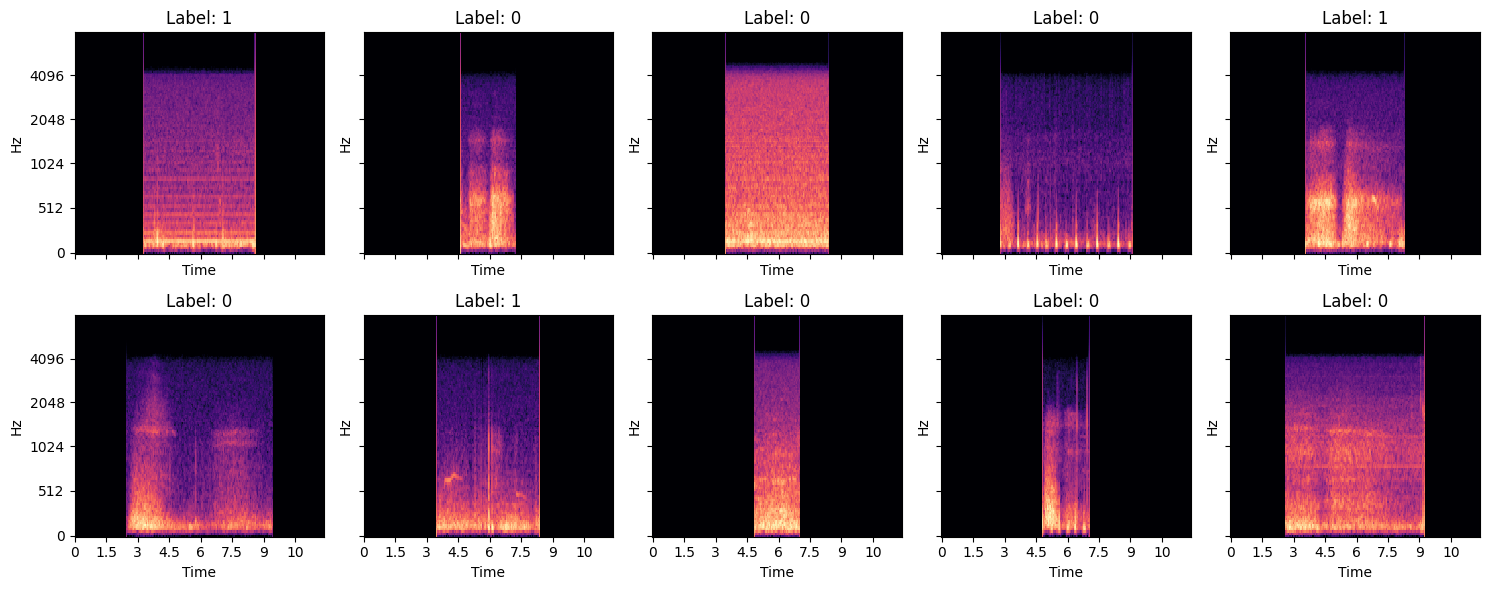

In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(15,6), sharey=True, sharex=True)
for i in range(10):
    ax = axs[i//5, i%5]
    img = librosa.display.specshow(X_train_melspecs_aug[i].reshape(128, -1), sr=16000, x_axis='time', y_axis='mel', n_fft=1024, ax=ax, cmap='magma')
    ax.set_title(f'Label: {y_train[i]}')
plt.tight_layout();

In [ ]:
np.savez_compressed(
    f'./dataset/ciclos_procesados/{dataset}/train_melspectrogram_aug.npz',
    X=X_train_melspecs_aug,
    y=y_train_augmented
)

np.savez_compressed(
    f'./dataset/ciclos_procesados/{dataset}/test_melspectrogram_aug.npz',
    X=X_test_melspecs_aug,
    y=y_test_augmented
)

# np.savez_compressed(
#     f'./dataset/ciclos_procesados/{dataset}/train_melspectrogram.npz',
#     X=X_train_melspecs,
#     y=y_train
# )

# np.savez_compressed(
#     f'./dataset/ciclos_procesados/{dataset}/test_melspectrogram.npz',
#     X=X_test_melspecs,
#     y=y_test
# )

#### Features

In [30]:
pipeline_feature_extraction = Pipeline([
    ('bandpass', BandPassFilter()),
    ('feature_extractor', FeatureExtractor())
])

In [ ]:
# X_train_features = pipeline_feature_extraction.fit_transform(X_train_resampled)
X_train_features_aug = pipeline_feature_extraction.transform(X_train_augmented)

In [ ]:
# X_test_features = pipeline_feature_extraction.transform(X_test_resampled)
X_test_features_aug = pipeline_feature_extraction.transform(X_test_augmented)

In [ ]:
# np.savez_compressed(
#     f'./dataset/ciclos_procesados/{dataset}/train_features.npz',
#     X=X_train_features,
#     y=y_train
# )

# np.savez_compressed(
#     f'./dataset/ciclos_procesados/{dataset}/test_features.npz',
#     X=X_test_features,
#     y=y_test
# )

np.savez_compressed(
    f'./dataset/ciclos_procesados/{dataset}/train_features_aug.npz',
    X=X_train_features_aug,
    y=y_train_augmented
)

np.savez_compressed(
    f'./dataset/ciclos_procesados/{dataset}/test_features_aug.npz',
    X=X_test_features_aug,
    y=y_test_augmented
)

## Imagenes

In [34]:
def plot_mel_spectrogram(y, sr=SAMPLING_RATE, ax=None, cmap='magma'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax, cmap=cmap);

def normalize_spec(spec):
    spec_min, spec_max = spec.min(), spec.max()
    spec = (spec - spec_min) / (spec_max - spec_min + 1e-6)
    spec = (spec * 255).astype(np.uint8)
    return spec

def spec_to_rgb(spec):
    spec = normalize_spec(spec)
    spec_color = cm.magma(spec / 255.0)[:, :, :3]  # RGB float 0–1
    return (spec_color * 255).astype(np.uint8)

def save_mel_images(X, y, split_name, dataset):
    output_dir = f'./dataset/ciclos_procesados/{dataset}/{split_name}_imgs'
    os.makedirs(output_dir, exist_ok=True)

    filenames = []
    for i, spec in enumerate(X):
        spec_rgb = spec_to_rgb(np.flipud(spec))
        # cv2 usa BGR → convertimos para guardar bien los colores
        cv2.imwrite(os.path.join(output_dir, f"{i}.png"), cv2.cvtColor(spec_rgb, cv2.COLOR_RGB2BGR))
        filenames.append(f"{i}.png")

    pd.DataFrame({
        'filename': filenames,
        'label': y
    }).to_csv(f'{output_dir}/labels.csv', index=False)

Guardar imagenes

In [ ]:
# save_mel_images(X_train_melspecs.reshape(-1, 128, 372), y_train, 'train', dataset)
# save_mel_images(X_test_melspecs.reshape(-1, 128, 372), y_test, 'test', dataset)

save_mel_images(X_train_melspecs_aug.reshape(-1, 128, 372), y_train_augmented, 'train_aug', dataset)
save_mel_images(X_test_melspecs_aug.reshape(-1, 128, 372), y_test_augmented, 'test_aug', dataset)

Para las NN necesito un conjunto de validacion

In [ ]:
# X_train_melspecs, X_val_melspecs, y_train, y_val = train_test_split(
#     X_train_melspecs, y_train, test_size=0.2, random_state=SEED, stratify=y_train
# )

X_train_melspecs_aug, X_val_melspecs_aug, y_train_augmented, y_val_augmented = train_test_split(
    X_train_melspecs_aug, y_train_augmented, test_size=0.2, random_state=SEED, stratify=y_train_augmented
)

In [ ]:
# save_mel_images(X_train_melspecs.reshape(-1, 128, 372), y_train, 'cnn/train', dataset)
# save_mel_images(X_val_melspecs.reshape(-1, 128, 372), y_val, 'cnn/val', dataset)
# save_mel_images(X_test_melspecs.reshape(-1, 128, 372), y_test, 'cnn/test', dataset)

save_mel_images(X_train_melspecs_aug.reshape(-1, 128, 372), y_train_augmented, 'cnn/train_aug', dataset)
save_mel_images(X_val_melspecs_aug.reshape(-1, 128, 372), y_val_augmented, 'cnn/val_aug', dataset)
save_mel_images(X_test_melspecs_aug.reshape(-1, 128, 372), y_test_augmented, 'cnn/test_aug', dataset)

In [ ]:
# np.savez_compressed(
#     f'./dataset/ciclos_procesados/{dataset}/cnn/train_melspectrogram.npz',
#     X=X_train_melspecs,
#     y=y_train
# )

# np.savez_compressed(
#     f'./dataset/ciclos_procesados/{dataset}/cnn/val_melspectrogram.npz',
#     X=X_val_melspecs,
#     y=y_val
# )

# np.savez_compressed(
#     f'./dataset/ciclos_procesados/{dataset}/cnn/test_melspectrogram.npz',
#     X=X_test_melspecs,
#     y=y_test
# )

np.savez_compressed(
    f'./dataset/ciclos_procesados/{dataset}/cnn/train_melspectrogram_aug.npz',
    X=X_train_melspecs_aug,
    y=y_train_augmented
)

np.savez_compressed(
    f'./dataset/ciclos_procesados/{dataset}/cnn/val_melspectrogram_aug.npz',
    X=X_val_melspecs_aug,
    y=y_val_augmented
)

np.savez_compressed(
    f'./dataset/ciclos_procesados/{dataset}/cnn/test_melspectrogram_aug.npz',
    X=X_test_melspecs_aug,
    y=y_test_augmented
)